In [1]:
%matplotlib inline

from glob import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']

In [2]:
LABELS = {
    'rej.enc'       : 'Fast Loaded Dice Roller (FLDR)',
    'alias.exact'   : 'Exact Alias Sampler',
    'alias.integers_old' : 'Alias Integers',
    'aldr'          : 'ALDR',
    'alias.rust'    : 'Alias Rust',
    'alias.fractions' : 'Alias Fractions',
}

In [3]:
def get_entropy(fname):
    with open(fname, 'r') as f:
        return float(f.readlines()[-1])
    
def parse_decimal(value):
    if hasattr(value, "decode"):
        value = value.decode()
    return float(value.replace(",", "."))

In [4]:
# Penser à changer le n et le Z en fonction du dossier que l'on veut charger
n = 1025
Z = 4097

# n = 1000
# Z = 40001

seed = 2
pattern = '/dists.%d.%d.%d' % (n, Z, seed)
f_runtimes = sorted(glob('../%s/*.runtimes' % (pattern,)))
f_sizes = sorted(glob('../%s/*.sizes' % (pattern,)))
f_dists = sorted(glob('../%s/*.dist' % (pattern,)))
f_bits = sorted(glob('../%s/*.bits' % (pattern,)))
runtimes = np.asarray([np.loadtxt(f) for f in f_runtimes])
sizes = np.asarray([np.loadtxt(f) for f in f_sizes])
entropies = np.asarray([get_entropy(f) for f in f_dists])
#bits = np.asarray([np.loadtxt(f) for f in f_bits])
bits = np.asarray([np.loadtxt(f, converters={0: parse_decimal}) for f in f_bits])
num_samples = 1e6
rates = runtimes / num_samples
samplers = [x.split('/')[-1].replace('.runtimes', '') for x in f_runtimes]

In [5]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'sans-serif'

#### Plot Memory--Rate

In [6]:
selection = [
    #'rej.enc',
    #'alias.exact',
    'alias.integers_old',
    'aldr',
    'alias.rust',
    'alias.fractions',
]

In [7]:
samplers

['aldr', 'alias.fractions', 'alias.integers_old', 'alias.rust']

In [8]:
def run_plot_rate_size(samplers, rates, sizes):
    fig, ax = plt.subplots()
    collections = []
    
    for sampler, rate, size in zip(samplers, rates, sizes):
        if sampler not in selection:
            continue
        print(sampler)
        sc = ax.scatter(rate, size, label=LABELS[sampler], s=10, marker='.', alpha=1)
        collections.append((sampler, sc))

    ax.set_xscale('log', base=2)
    ax.set_yscale('log', base=2)

    ax.set_xlabel('Sampler Runtime (Seconds per Sample)', fontsize=14)
    ax.set_ylabel('Sampler Memory (Bytes)', fontsize=14)

    ax.xaxis.set_major_locator(
        ticker.LogLocator(base=2., subs=(1,), numticks=100))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.xaxis.set_minor_locator(
        ticker.LogLocator(base=2., subs=np.arange(11, 20)*.1, numticks=24))

    ax.yaxis.set_major_locator(
        ticker.LogLocator(base=2., subs=(1,), numticks=20))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.yaxis.set_minor_locator(
        ticker.LogLocator(base=2., subs=np.arange(11,20)*.1, numticks=100))

    fig.set_size_inches((8, 6))
    fig.set_facecolor('white')
    fig.set_tight_layout(True)
    
    return fig, ax, collections

aldr
alias.fractions
alias.integers_old
alias.rust


/var/folders/jm/qw405wwx4y588pcz202jwwgw0000gn/T/ipykernel_25721/2562219533.py:47: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.savefig('figure-4-interpolation-runtime-memory.%s' % (ext,))
/Users/oriane/Library/Python/3.9/lib/python/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  func(*args, **kwargs)
/Users/oriane/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


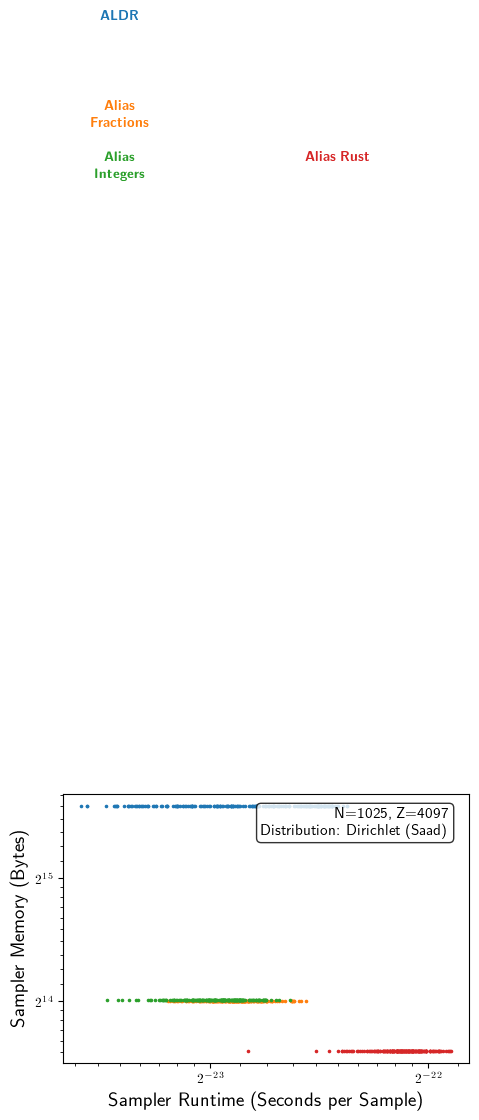

In [9]:
fig, ax, collections = run_plot_rate_size(samplers, rates, sizes)

# Create a mapping of sampler names to colors
sampler_colors = {sampler: sc.get_facecolors()[0] for sampler, sc in collections}

#ax.set_xlim([1.8*2**-25, 2**-21])
#ax.set_ylim([2**17, 1.5*2**21])

# Add legend for N, Z, warmup status, and distribution type at top right
legend_text = f'N={n}, Z={Z}\nDistribution: Dirichlet (Saad)'
ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Add labels with matching colors
# ax.text(
#     0.75*2**-21, 1.3*2**20,
#     r'\begin{center}\textbf{Alias}\\\textbf{Walker}\end{center}',
#     horizontalalignment='center',
#     color=sampler_colors['alias.exact'])
# ax.text(
#     0.8*2**-23, 1.3*2**21,
#     r'\begin{center}\textbf{Fast Loaded Dice}\\\textbf{Roller (FLDR)}\end{center}',
#     horizontalalignment='center',
#     color=sampler_colors['rej.enc'])
ax.text(
    1.5*2**-24, 2**22,
    r'\begin{center}\textbf{ALDR}\end{center}',
    horizontalalignment='center',
    color=sampler_colors['aldr'])
ax.text(
    1.5*2**-23, 0.45*2**22,
    r'\begin{center}\textbf{Alias Rust}\end{center}',
    horizontalalignment='center',
    color=sampler_colors['alias.rust'])
ax.text(
    1.5*2**-24, 0.45*2**22,
    r'\begin{center}\textbf{Alias}\\\textbf{Integers}\end{center}',
    horizontalalignment='center',
    color=sampler_colors['alias.integers_old'])
ax.text(
    1.5*2**-24, 0.6*2**22,
    r'\begin{center}\textbf{Alias}\\\textbf{Fractions}\end{center}',
    horizontalalignment='center',
    color=sampler_colors['alias.fractions'])
fig.set_tight_layout(True)
fig.set_size_inches(5.25, 3.5)
for ext in ['pdf', 'png']:
    fig.savefig('figure-4-interpolation-runtime-memory.%s' % (ext,))

#### Plot Entropy--Rate

In [10]:
from scipy.signal import savgol_filter

In [11]:
def run_plot_entropy_rate(samplers, entropies, rates):
    fig, ax = plt.subplots()

    for sampler, rate in zip(samplers, rates):
        if sampler not in selection:
            continue

        sc = ax.scatter([], [], label=rf'\textbf{{{LABELS[sampler]}}}', s=50)
        color = sc.get_facecolors()[0]

        ax.scatter(entropies, rate, color=color, marker='.', s=2)

        # # Régression SANS sklearn
        x = entropies
        y = np.log2(rate)

        a, b = np.polyfit(x, y, 1)

        x_line = np.linspace(x.min(), x.max(), 200)
        y_line = 2 ** (a * x_line + b)

        ax.plot(x_line, y_line, linestyle='--', color=color)

        print(f"{sampler} slope (entropy): {a:.3f}")

    ax.set_yscale('log', base=2)

    ax.set_xlabel('Entropy of Target Distribution', fontsize=14)
    ax.set_ylabel('Sampler Runtime (Seconds per Sample)', fontsize=12)

    ax.legend(loc='upper left', bbox_to_anchor=(1,1))

    fig.set_tight_layout(True)
    fig.set_size_inches((8, 6))

    return fig, ax

aldr slope (entropy): 0.155
alias.fractions slope (entropy): 0.017
alias.integers_old slope (entropy): 0.006
alias.rust slope (entropy): -0.001


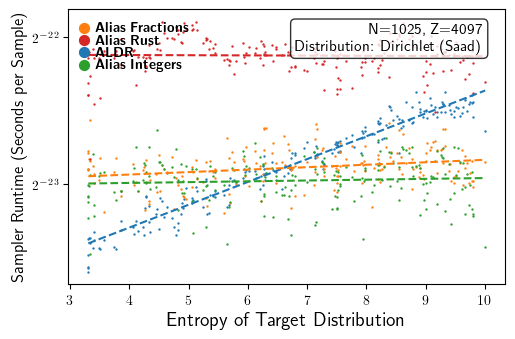

In [12]:
fig, ax = run_plot_entropy_rate(samplers, entropies, rates)

#ax.set_xlim([0, 10])
#ax.set_ylim([0.8*2**-24, 2**-20])

# Add legend for N, Z, warmup status, and distribution type at top right
legend_text = f'N={n}, Z={Z}\nDistribution: Dirichlet (Saad)'
ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

handles, labels = ax.get_legend_handles_labels()
order = [6, 1, 3, 5, 0, 4, 2]
order = [i for i in order if i < len(handles)]
ax.legend(
    [handles[idx] for idx in order],
    [labels[idx] for idx in order],
    loc='upper left',
    framealpha=0,
    labelspacing=0,
    handletextpad=.5,
    handlelength=.5,
#     bbox_to_anchor=(1,1),
)

fig.set_tight_layout(True)
fig.set_size_inches(5.25, 3.5)
for ext in ['pdf', 'png']:
    fig.savefig('figure-4-interpolation-entropy-runtimes.%s' % (ext,))

#### Plot Entropy--Bits

In [13]:
def run_plot_entropy_bits(samplers, entropies, bits):
    fig, ax = plt.subplots()

    for sampler, bit in zip(samplers, bits):
        if sampler not in selection:
            continue

        sc = ax.scatter([], [], label=rf'\textbf{{{LABELS[sampler]}}}', s=50)
        color = sc.get_facecolors()[0]

        ax.scatter(entropies, bit, color=color, marker='.', s=2)

        # Régression SANS sklearn
        x = entropies
        #y = np.log2(bit)
        y = bit

        a, b = np.polyfit(x, y, 1)

        x_line = np.linspace(x.min(), x.max(), 200)
        #y_line = 2 ** (a * x_line + b)
        y_line = (a * x_line + b)

        ax.plot(x_line, y_line, linestyle='--', color=color)

        print(f"{sampler} slope (entropy): {a:.3f}")

    ax.set_yscale('linear')

    ax.set_xlabel('Entropy of Target Distribution', fontsize=14)
    ax.set_ylabel('Average number of bits consumed', fontsize=12)

    ax.legend(loc='upper left', bbox_to_anchor=(1,1))

    fig.set_tight_layout(True)
    fig.set_size_inches((8, 6))

    return fig, ax

aldr slope (entropy): 1.038
alias.fractions slope (entropy): 0.000
alias.integers_old slope (entropy): -0.072
alias.rust slope (entropy): 0.000


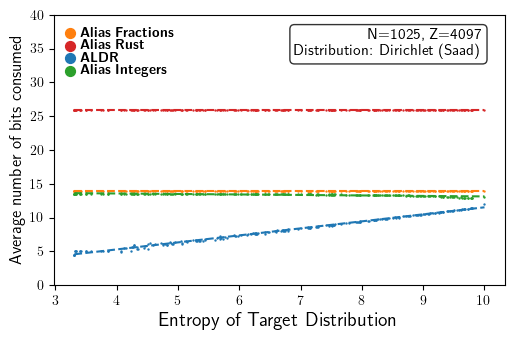

In [14]:
fig, ax = run_plot_entropy_bits(samplers, entropies, bits)

#ax.set_xlim([0, 10])
ax.set_ylim([0, 40])

# Add legend for N, Z, warmup status, and distribution type at top right
legend_text = f'N={n}, Z={Z}\nDistribution: Dirichlet (Saad)'
ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

handles, labels = ax.get_legend_handles_labels()
order = [6, 1, 3, 5, 0, 4, 2]
order = [i for i in order if i < len(handles)]
ax.legend(
    [handles[idx] for idx in order],
    [labels[idx] for idx in order],
    loc='upper left',
    framealpha=0,
    labelspacing=0,
    handletextpad=.5,
    handlelength=.5,
#     bbox_to_anchor=(1,1),
)

fig.set_tight_layout(True)
fig.set_size_inches(5.25, 3.5)
for ext in ['pdf', 'png']:
    fig.savefig('figure-4-interpolation-entropy-bits.%s' % (ext,))

#### Plot Entropy--Memory

In [15]:
def run_plot_entropy_memory(samplers, entropies, sizes):
    fig, ax = plt.subplots()

    for sampler, bit in zip(samplers, sizes):
        if sampler not in selection:
            continue

        sc = ax.scatter([], [], label=rf'\textbf{{{LABELS[sampler]}}}', s=50)
        color = sc.get_facecolors()[0]

        ax.scatter(entropies, bit, color=color, marker='.', s=2)

        # Régression SANS sklearn
        #x = entropies
        #y = np.log2(bit)
        # y = bit

        #a, b = np.polyfit(x, y, 1)

        #x_line = np.linspace(x.min(), x.max(), 200)
        #y_line = 2 ** (a * x_line + b)
        #y_line = (a * x_line + b)

        #ax.plot(x_line, y_line, linestyle='--', color=color)

        #print(f"{sampler} slope (entropy): {a:.3f}")

    ax.set_yscale('log', base=2)

    ax.set_xlabel('Entropy of Target Distribution', fontsize=14)
    ax.set_ylabel('Sampler Memory (Bytes)', fontsize=12)

    ax.legend(loc='upper left', bbox_to_anchor=(1,1))

    fig.set_tight_layout(True)
    fig.set_size_inches((8, 6))

    return fig, ax

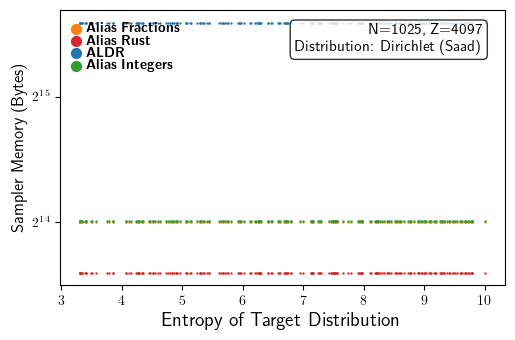

In [16]:
fig, ax = run_plot_entropy_memory(samplers, entropies, sizes)

#ax.set_xlim([0, 10])
#ax.set_ylim([1.2*2**19, 1.5*2**22])

# Add legend for N, Z, warmup status, and distribution type at top right
legend_text = f'N={n}, Z={Z}\nDistribution: Dirichlet (Saad)'
ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

handles, labels = ax.get_legend_handles_labels()
order = [6, 1, 3, 5, 0, 4, 2]
order = [i for i in order if i < len(handles)]
ax.legend(
    [handles[idx] for idx in order],
    [labels[idx] for idx in order],
    loc='upper left',
    framealpha=0,
    labelspacing=0,
    handletextpad=.5,
    handlelength=.5,
#     bbox_to_anchor=(1,1),
)

fig.set_tight_layout(True)
fig.set_size_inches(5.25, 3.5)
for ext in ['pdf', 'png']:
    fig.savefig('figure-4-interpolation-entropy-memory.%s' % (ext,))

#### Plot Sampling Time (sec)--Bits

In [17]:
def run_plot_entropy_bits(samplers, rates, bits):
    fig, ax = plt.subplots()

    for sampler, rate, bit in zip(samplers, rates, bits):
        if sampler not in selection:
            continue

        sc = ax.scatter([], [], label=rf'\textbf{{{LABELS[sampler]}}}', s=50)
        color = sc.get_facecolors()[0]

        ax.scatter(rate, bit, color=color, marker='.', s=2)

        x = rate
        y = bit

        a, b = np.polyfit(x, y, 1)

        x_line = np.linspace(x.min(), x.max(), 200)
        y_line = (a * x_line + b)

        ax.plot(x_line, y_line, linestyle='--', color=color)

        print(f"{sampler} slope (sampling time): {a:.3f}")

    ax.set_yscale('linear')

    ax.set_xlabel('Sampling Time (sec)', fontsize=14)
    ax.set_ylabel('Average number of bits consumed', fontsize=12)

    ax.legend(loc='upper left', bbox_to_anchor=(1,1))

    fig.set_tight_layout(True)
    fig.set_size_inches((8, 6))

    return fig, ax

aldr slope (sampling time): 70796216.192
alias.fractions slope (sampling time): -12927.195
alias.integers_old slope (sampling time): 318363.500
alias.rust slope (sampling time): 676.987


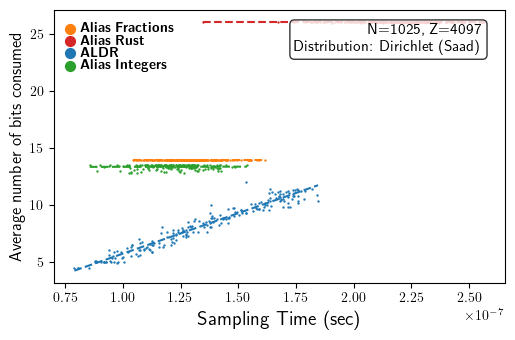

In [18]:
fig, ax = run_plot_entropy_bits(samplers, rates, bits)

#ax.set_xlim([0, 10])
#ax.set_ylim([10, 15])

# Add legend for N, Z, warmup status, and distribution type at top right
legend_text = f'N={n}, Z={Z}\nDistribution: Dirichlet (Saad)'
ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, ha='right', va='top', fontsize=11, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

handles, labels = ax.get_legend_handles_labels()
order = [6, 1, 3, 5, 0, 4, 2]
order = [i for i in order if i < len(handles)]
ax.legend(
    [handles[idx] for idx in order],
    [labels[idx] for idx in order],
    loc='upper left',
    framealpha=0,
    labelspacing=0,
    handletextpad=.5,
    handlelength=.5,
#     bbox_to_anchor=(1,1),
)

fig.set_tight_layout(True)
fig.set_size_inches(5.25, 3.5)
for ext in ['pdf', 'png']:
    fig.savefig('figure-4-interpolation-runtime-bits.%s' % (ext,))